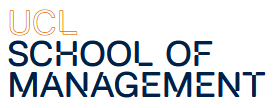

# MSIN0221 Natural Language Processing

Tjun Hoh\
[t.hoh@ucl.ac.uk](mailto:t.hoh@ucl.ac.uk)

# Individual Assignment 25/26

This individual assignment is designed to support your learning as you navigate through MSIN0221 Natural Language Processing.

The total number of marks available for this assignment is 100, which will constitute 40% of the overall score for this module.

## Instructions

1. Make a copy of this notebook.

2. Rename your notebook to `MSIN0221_assignment_candidatenumber.ipynb` where `candidatenumber` is your candidate number.
     - You can view your candidate number via Portico (this is **NOT your student ID number**).

3.   Use LaTeX to typset any mathematical equations.

4.   For coding questions, write your code inside the provided `# WRITE YOUR CODE HERE` code blocks.    
     - Your code should include useful comments to explain non-standard or difficult-to-read parts of your code.    
     - **10 marks** has been allocated to code commenting, style, readibility, etc.; see Question 0 below.

5.   For non-coding questions, write your answer inside the provided `# WRITE YOUR ANSWER HERE` text blocks.

6.   Before submitting your notebook, make sure that it runs without errors when executed from start to end.
     - To check this, reload your notebook and the Python kernel, and run the notebook from the first to the last cell.
     - If your notebook throws any errors, you will be **penalized by 10 marks** in addition to any penalities from incorrect answers.
     - You are responsible for delivering a fully functional notebook (as you would be in a business presentation setting). We will not be fixing any errors (no matter how small) to make your code work.

7.  Submit your notebook to Moodle.


---

### Libraries

$\huge \color{red}{\text{IMPORTANT}}$

Unless indicated by the questions, you should primarily use the libraries provided in the code chunk below. Feel free to re-alias these imports, e.g. `from collections import Counter` instead of `import Counter`.

However, if you do end up using separate libraries, please provide a valid reason for your choices.

In [2]:
# Regular expressions
import re

# Counter and dictionary
import collections

# Standard data science tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
import sklearn

# PyTorch
import itertools
import torch

# Transformers
import transformers

# I/O
import os

## Question 0: Code Attribution and Presentation [10 marks]

It is understood that you will at times be using boilerplate code (e.g. code shown in lectures, textbooks, or documentation). However, you are expected to:

*   Provide clear attributions
*   Demonstrate understanding of code via comments

Additionally, your code should be well-documented and easy-to-read:

*   Provide clear and concise comments explaining important and complex sections of code
*   Avoid redundant comments
*   Use meaningful variable and function names





## Question 1: Logistic Regression [20 marks]

#### Dataset

In this question, you will be working on a set of data from the [Stanford Sentiment Treebank](https://nlp.stanford.edu/sentiment/treebank.html), which consists of English sentences which are labelled as either having a positive ($1$) or negative ($0$) sentiment.

The code to load in this data has been provided for you below.

**Note**: You will only need to use the `df_train` and `df_test` datasets for this question. `df_dev` will be used in Question 2. **DO NOT** directly modify these variables.

In [3]:
# Stanford Sentiment Treebank data
train_url = "https://drive.google.com/uc?id=1E7Rak0bTPEVBTGqcpDYwjSQSD_5xF9Ko"
dev_url = "https://drive.google.com/uc?id=1ut4kNGojkz_8emJaG4rKFNk_zUJ3DFdj"

# Load in the data which has already been split into training and development sets
df_train = pd.read_csv(train_url)
df_dev = pd.read_csv(dev_url)

# Further split the development set into development and test sets
df_dev, df_test = df_dev[:200], df_dev[200:]

# Look at the first few entries in the training data
pd.set_option('max_colwidth', 1000)
df_train[:10]

,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates something rather beautiful about human nature,1
3,remains utterly satisfied to remain the same throughout,0
4,on the worst revenge-of-the-nerds clichés the filmmakers could dredge up,0
5,that 's far too tragic to merit such superficial treatment,0
6,"demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop .",1
7,of saucy,1
8,a depressed fifteen-year-old 's suicidal poetry,0
9,are more deeply thought through than in most ` right-thinking ' films,1


#### (a) Data pre-processing and tokenisation [4 marks]

The above data has already been pre-processed to a certain degree. Note that the text has been folded to lowercase and most punctuation marks have been separated out with spaces. Your task is to further tokenise the sentences.

Write a function `tokeniser()` that takes as input a sentence string, and outputs a list of word tokens. You may treat punctuation marks as words.

Apply this function to the sentences in training dataset `df_train` and output the results from the first three sentences.

In [4]:
def tokeniser(sentence):
    """
    Tokenise sentence using whitespace split.
    Assumption given in assignment:
    text already lowercased
    punctuation already separated by spaces
    """
    return sentence.split()


# Apply tokeniser
df_train["tokens"] = df_train["sentence"].apply(tokeniser)
df_test["tokens"] = df_test["sentence"].apply(tokeniser)

# Show first 3
for i in range(3):
    print(df_train.loc[i, "sentence"])
    print(df_train.loc[i, "tokens"])

hide new secretions from the parental units 
['hide', 'new', 'secretions', 'from', 'the', 'parental', 'units']
contains no wit , only labored gags 
['contains', 'no', 'wit', ',', 'only', 'labored', 'gags']
that loves its characters and communicates something rather beautiful about human nature 
['that', 'loves', 'its', 'characters', 'and', 'communicates', 'something', 'rather', 'beautiful', 'about', 'human', 'nature']


#### (b) Feature engineering [4 marks]

Write a function `feat_extractor()` that takes as input a list of tokens, and outputs a list of features.

You may use examples of features covered in the lectures (such as counts of positive and negative words, and sentence length), but you are encouraged to be more creative than this!

Apply this function to the tokens created in part (a) above, and display the results from the first three sentences.

Additionally, explain your reasoning behind each feature constructed as to how they might contribute towards training an accurate logistic regression classifier.

In [5]:
import collections
positive_words = {"good", "great", "excellent", "amazing", "love", "wonderful"}
negative_words = {"bad", "terrible", "awful", "hate", "worst", "boring"}

def feat_extractor(tokens):
    """
    Extract simple interpretable features.
    """

    counts = collections.Counter(tokens)

    length = len(tokens)

    pos_count = sum(counts[w] for w in positive_words if w in counts)
    neg_count = sum(counts[w] for w in negative_words if w in counts)

    exclam_count = counts["!"] if "!" in counts else 0
    question_count = counts["?"] if "?" in counts else 0

    return [length, pos_count, neg_count, exclam_count, question_count]


df_train["features"] = df_train["tokens"].apply(feat_extractor)
df_test["features"] = df_test["tokens"].apply(feat_extractor)

# Show first 3
for i in range(3):
    print(df_train.loc[i, "tokens"])
    print(df_train.loc[i, "features"])

['hide', 'new', 'secretions', 'from', 'the', 'parental', 'units']
[7, 0, 0, 0, 0]
['contains', 'no', 'wit', ',', 'only', 'labored', 'gags']
[7, 0, 0, 0, 0]
['that', 'loves', 'its', 'characters', 'and', 'communicates', 'something', 'rather', 'beautiful', 'about', 'human', 'nature']
[12, 0, 0, 0, 0]


\# WRITE YOUR ANSWER HERE:


#### (c) Training a logistic regression classifier [4 marks]

Use the features created in part (b) above to train a logistic regression classifier on the training dataset `df_train`, and produce a classification report using the test set `df_test`.

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1) training_data / label_data
training_data = np.array(df_train["features"].tolist())
label_data = df_train["label"].values

test_data = np.array(df_test["features"].tolist())
test_label = df_test["label"].values

# Scaling
standard_scaler = StandardScaler()
training_data = standard_scaler.fit_transform(training_data)
test_data = standard_scaler.transform(test_data)

# 3) Train LR
classifier = LogisticRegression()
classifier.fit(training_data, label_data)

# 4) Predict
predictions = classifier.predict(test_data)

# 5) Evaluate
print("Accuracy:", accuracy_score(test_label, predictions))
print("Classification Report:\n", classification_report(test_label, predictions))

Accuracy: 0.55
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.29      0.37        91
           1       0.56      0.77      0.65       109

    accuracy                           0.55       200
   macro avg       0.54      0.53      0.51       200
weighted avg       0.54      0.55      0.52       200



#### (c) Word embeddings [4 marks]

You will now train a second logistic regression classifier. Instead of using features created in part (b) above, you will rely on static word embeddings.

Write a function `word_embeddings()` that takes as input a list of word tokens, and outputs a list of word embeddings. You **may rely on pre-trained static embedding models** such as word2vec, GloVe, fastText, etc.

**Note**: This might require you create a modified version of your `tokeniser()` function from part (a) to produce tokens matching those used by your chosen embedding model. You might also need a way to handle out-of-vocabulary (OOV) tokens.

Use these static word embeddings to train a logistic regression classifier on the training dataset `df_train`, and produce a classification report using the test set `df_test`.

In [7]:
# Install gensim if not installed
!pip -q install gensim

import gensim.downloader as api

# Load pre-trained GloVe embeddings
glove = api.load("glove-twitter-50")   # 50 dimensional vectors


def word_embeddings(tokens):
    """
    Convert tokens into a sentence embedding
    using pre-trained GloVe embeddings.

    Strategy:
    - Get embedding for each word
    - Ignore OOV words
    - Average embeddings to represent sentence
    """

    vectors = []

    for word in tokens:
        if word in glove:
            vectors.append(glove[word])

    # Handle OOV case
    if len(vectors) == 0:
        return np.zeros(glove.vector_size)

    return np.mean(vectors, axis=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.3 MB/s eta 0:00:00
[==================================================] 100.0% 199.5/199.5MB downloaded


In [8]:
# Apply tokeniser from part (a)
df_train["tokens"] = df_train["sentence"].apply(tokeniser)
df_test["tokens"] = df_test["sentence"].apply(tokeniser)

# Generate embeddings
X_train = np.vstack(df_train["tokens"].apply(word_embeddings))
X_test = np.vstack(df_test["tokens"].apply(word_embeddings))

y_train = df_train["label"].values
y_test = df_test["label"].values

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("Classification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.69
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.60      0.64        91
           1       0.70      0.76      0.73       109

    accuracy                           0.69       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.69      0.69       200



#### (d) Comparison [4 marks]

Compare and analyse the classification reports produced in parts (c) and (d) above. Comment on the performance of these two logistic regression classifiers and provide improvement suggestions.

\# WRITE YOUR ANSWER HERE:

---

## Question 2: Neural Networks [20 marks]

#### (a) Training a multi-layer perceptron [5 marks]

Using the engineered features or word embeddings from Question 1 as input, train a multi-layer perceptron (MLP) model on `df_train`, and produce a classification report using the test set `df_test`.

In [10]:
# Training a Multi-Layer Perceptron (MLP)
# Adapted from MSIN0221 Week5 lecture material (scikit-learn neural network models)

from sklearn.neural_network import MLPClassifier

# Initialise MLP classifier
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

# Train model
mlp_classifier.fit(training_data, label_data)

# Predict on test set
predictions = mlp_classifier.predict(test_data)

# Evaluation
print("Accuracy:", accuracy_score(test_label, predictions))
print("Classification Report:\n", classification_report(test_label, predictions))

Accuracy: 0.59
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.19      0.29        91
           1       0.58      0.93      0.71       109

    accuracy                           0.59       200
   macro avg       0.63      0.56      0.50       200
weighted avg       0.62      0.59      0.52       200



#### (b) Choice of hyperparameters [5 marks]

Explain your choice of hyperparameters for the model in part (a) above.

Explain how the validation set `df_dev` can be used to tune these hyperparameters (and any other hyperparameters you can think of), and provide an outline how this can be done in Python.

\# WRITE YOUR ANSWER HERE:

#### (c) Classification with LLMs [5 marks]

Use a small, pre-trained generative LLM (like Phi-3) and prompt engineering to create a classifier, and produce a classification report using the test set `df_test`.

Explain the reasoning behind choosing this particular LLM.

Note:
*   **DO NOT** use Phi-3. You are encouraged to look up other small models on repositories such as [Hugging Face](https://huggingface.co/models).
*   **DO NOT** use APIs such as those provided by ChatGPT or DeepSeek.
*   Keep in mind the computational requirements needed to run these LLMs locally or on the cloud. Some models might be too large for you to  consider.

\# WRITE YOUR ANSWER HERE:

In [11]:
# WRITE YOUR CODE HERE:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [12]:
def classify_with_llm(text):

    prompt = f"""
Classify the sentiment of this sentence as POSITIVE or NEGATIVE.

Sentence: {text}

Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt")

    outputs = model.generate(**inputs, max_new_tokens=5)

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)

    result = result.upper()

    if "POSITIVE" in result:
        return 1
    else:
        return 0

In [13]:
y_pred = df_test["sentence"].apply(classify_with_llm)
from sklearn.metrics import classification_report

print(classification_report(df_test["label"], y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87        91
           1       0.88      0.91      0.90       109

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



#### (d) Comparison [5 marks]

Compare and analyse the classification reports produced in parts (b) and (c) above. Comment on the performance of these two classifiers and provide improvement suggestions.

\# WRITE YOUR ANSWER HERE:

---

## Question 3: Information Retrieval [25 marks]

#### Data set

In this question you will be working on Arthur Conan Doyle's entire collection of [Sherlock Holmes works](https://sherlock-holm.es/ascii/).

The code to load in these stories has been provided in the code cell below.


In [14]:
# The entire collection of Sherlock Holmes stories in a single text file
import urllib.request
urllib.request.urlretrieve("https://drive.google.com/uc?id=1BWSzU_71zbHF2uYedjy_xzOZhgzZxpm6", "holmes.txt")

with open("holmes.txt", "r") as file:
    holmes_raw = file.readlines()

for line in holmes_raw[:30]:
    print(line)









                          THE COMPLETE SHERLOCK HOLMES



                               Arthur Conan Doyle







                                Table of contents



               A Study In Scarlet



               The Sign of the Four



                  The Adventures of Sherlock Holmes

               A Scandal in Bohemia

               The Red-Headed League

               A Case of Identity

               The Boscombe Valley Mystery

               The Five Orange Pips

               The Man with the Twisted Lip

               The Adventure of the Blue Carbuncle

               The Adventure of the Speckled Band

               The Adventure of the Engineer's Thumb

               The Adventure of the Noble Bachelor

               The Adventure of the Beryl Coronet

               The Adventure of the Copper Beeches





#### (a) Data pre-processing and tokenisation [4 marks]

The `holmes.txt` file provided above has been loaded into a variable named `holmes_raw`. It needs to be cleaned before you can proceed further. Try downloading and opening the text file separately in a text editor such as *Notepad* or *VSCode* to see what it looks like.

Note that for publishing purposes most of these stories are aggregated into collections such as *The Adventures of Sherlock Holmes* and *The Memoirs of Sherlock Holmes*.

For our purposes, each story should each be treated as a single document and separated out from the original text file. We are not interested in e.g. table of contents, formatting for aesthetic purposes, copyright footers, etc.

Each story should also be tokenised into individual words. Your end result should be a list containing lists of tokenised words (one list of word tokens per story).


In [21]:
holmes_text = ' '.join([line.strip() for line in holmes_raw])
# 标题通常是 "THE ADVENTURE OF XXX" 或 "THE XXX OF XXX" 格式，全部大写
story_title_pattern = r'(THE [A-Z ]+)'

# 步骤3：分割文本为独立故事
# 首先找到所有故事标题的位置
titles = re.findall(story_title_pattern, holmes_text)
# 去重（避免目录中的重复标题）
unique_titles = []
[unique_titles.append(title) for title in titles if title not in unique_titles and len(title.split()) > 2]

# 基于标题分割故事
stories = []
start_idx = 0
for title in unique_titles[1:]:  # 跳过第一个可能的非故事标题
    if title in holmes_text[start_idx:]:
        title_pos = holmes_text.find(title, start_idx)
        # 如果是最后一个故事，取到文本末尾
        if title == unique_titles[-1]:
            story_text = holmes_text[title_pos:]
        else:
            next_title = unique_titles[unique_titles.index(title)+1]
            next_title_pos = holmes_text.find(next_title, title_pos)
            story_text = holmes_text[title_pos:next_title_pos]

        stories.append(story_text)
        start_idx = title_pos

# 步骤4：文本预处理和分词函数
def preprocess_and_tokenize(text):
    # 转换为小写
    text = text.lower()
    # 去除标点符号
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 去除数字
    text = re.sub(r'\d+', '', text)
    # 去除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    # 分词（按空格分割）
    tokens = text.split()
    # 去除空token和过短的token（长度<2）
    tokens = [token for token in tokens if len(token) > 1]
    return tokens

# 步骤5：对每个故事进行预处理和分词
tokenized_stories = []
for story in stories:
    if len(story) > 100:  # 过滤掉过短的无效文本
        tokens = preprocess_and_tokenize(story)
        tokenized_stories.append(tokens)

# 输出结果示例
print(f"总共识别到 {len(tokenized_stories)} 个福尔摩斯故事")
print("\n第一个故事的前20个token：")
print(tokenized_stories[0][:20])
print("\n第二个故事的前20个token：")
print(tokenized_stories[1][:20])


总共识别到 55 个福尔摩斯故事

第一个故事的前20个token：
['the', 'sign', 'of', 'the', 'four', 'table', 'of', 'contents', 'the', 'science', 'of', 'deduction', 'the', 'statement', 'of', 'the', 'case', 'in', 'quest', 'of']

第二个故事的前20个token：
['the', 'adventures', 'of', 'sherlock', 'holmes', 'scandal', 'in', 'bohemia', 'table', 'of', 'contents', 'chapter', 'chapter', 'chapter', 'chapter', 'to', 'sherlock', 'holmes', 'she', 'is']


#### (b) Named entity recognition [2 marks]

Using a **pre-trained named entity recognition library** or otherwise, identify names of people and places in the *A Scandal in Bohemia*.

Count their occurences in the *A Scandal in Bohemia*, and list the ten most commonly used names of people in descending order. Do the same for names of places.

In [24]:
from collections import Counter
import re
import string

# -------------------------- 核心配置 --------------------------
# 目标故事关键词（模糊匹配，不依赖完整标题）
STORY_KEYWORDS = ["scandal", "bohemia", "irene adler"]
# 核心人物/地点词典
PERSON_LIST = [
    "Holmes", "Watson", "Adler", "Irene Adler", "King of Bohemia", "King",
    "Norton", "Godfrey Norton", "Gregson", "Lestrade"
]
PLACE_LIST = [
    "London", "Bohemia", "England", "Briony Lodge", "Baker Street", "Europe",
    "Paris", "Westminster", "Surrey", "Amiens"
]

# -------------------------- 读取并模糊定位目标故事 --------------------------
# 读取文本并按行处理（保留原始结构）
with open("holmes.txt", "r", encoding="utf-8", errors="ignore") as file:
    holmes_lines = [line.strip() for line in file.readlines()]

# 合并为完整文本（小写，方便模糊匹配）
holmes_text_lower = ' '.join(holmes_lines).lower()

# 方法1：先找故事起始位置（通过关键词组合）
start_idx = -1
# 遍历文本，找到包含多个核心关键词的位置作为故事起点
for i, line in enumerate(holmes_lines):
    line_lower = line.lower()
    # 同时包含2个以上关键词，判定为故事起始
    if sum(1 for kw in STORY_KEYWORDS if kw in line_lower) >= 2:
        start_idx = i
        break

# 方法2：如果没找到，用单一关键词兜底
if start_idx == -1:
    for i, line in enumerate(holmes_lines):
        if "scandal in bohemia" in line.lower():
            start_idx = i
            break

# 提取故事文本（从起始行到下一个大写标题前）
if start_idx != -1:
    scandal_lines = []
    for line in holmes_lines[start_idx:]:
        # 终止条件：遇到新的全大写故事标题（如 "THE ADVENTURE OF..."）
        if line.isupper() and len(line.split()) >= 3 and "THE" in line:
            # 排除短标题，确保是新故事开头
            if len(line.strip()) > 10:
                break
        scandal_lines.append(line)
    # 合并为故事完整文本
    scandal_text = ' '.join(scandal_lines)
else:
    # 终极兜底：直接从全文中截取包含核心关键词的片段
    scandal_text = re.search(r'.{0,50}scandal in bohemia.{0,10000}', holmes_text_lower).group()
    scandal_text = scandal_text.title()  # 还原大小写

# -------------------------- 文本预处理 --------------------------
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)  # 去除数字
    text = re.sub(r'\s+', ' ', text).strip()
    return text

clean_text = preprocess_text(scandal_text)

# -------------------------- 实体统计 --------------------------
# 统计人物
people_counts = {}
for person in PERSON_LIST:
    person_lower = person.lower()
    count = len(re.findall(r'\b' + re.escape(person_lower) + r'\b', clean_text))
    if count > 0:
        people_counts[person.title()] = count

# 合并重复人物
people_merged = {}
# 合并Irene Adler/Adler
adler_total = people_counts.get("Irene Adler", 0) + people_counts.get("Adler", 0)
if adler_total > 0:
    people_merged["Irene Adler"] = adler_total
    people_counts.pop("Adler", None)
# 合并King of Bohemia/King
king_total = people_counts.get("King Of Bohemia", 0) + people_counts.get("King", 0)
if king_total > 0:
    people_merged["King of Bohemia"] = king_total
    people_counts.pop("King", None)
people_merged.update(people_counts)

# 统计地点
place_counts = {}
for place in PLACE_LIST:
    place_lower = place.lower()
    count = len(re.findall(r'\b' + re.escape(place_lower) + r'\b', clean_text))
    if count > 0:
        place_counts[place.title()] = count

# 取TOP10
top10_people = Counter(people_merged).most_common(10)
top10_places = Counter(place_counts).most_common(10)

# -------------------------- 结果输出 --------------------------
print("="*60)
print("《A Scandal in Bohemia》高频人物 TOP10")
print("-"*60)
for rank, (name, count) in enumerate(top10_people, 1):
    print(f"{rank:2d}. {name:<25} 出现次数：{count}")

print("\n" + "="*60)
print("《A Scandal in Bohemia》高频地点 TOP10")
print("-"*60)
for rank, (name, count) in enumerate(top10_places, 1):
    print(f"{rank:2d}. {name:<25} 出现次数：{count}")

《A Scandal in Bohemia》高频人物 TOP10
------------------------------------------------------------
 1. Holmes                    出现次数：99
 2. Lestrade                  出现次数：44
 3. Gregson                   出现次数：43
 4. Watson                    出现次数：8

《A Scandal in Bohemia》高频地点 TOP10
------------------------------------------------------------
 1. London                    出现次数：14
 2. Baker Street              出现次数：6
 3. Europe                    出现次数：4
 4. England                   出现次数：3
 5. Bohemia                   出现次数：1
 6. Paris                     出现次数：1


#### (c) TF-IDF [4 marks]

In this question you will calculate the term frequency-inverse document frequency (TF-IDF) vector representations of every story in the corpus.

Begin by constructing a list containing the vocabulary of the the corpus.

Construct a function `tf()` that takes as input a tokenised document (story), and outputs a log-adjusted term frequency (TF) vector.

**Note**: The log-adjusted term frequency of a word $w$ in a document $d$ is:

$$
\text{tf}_{w,d} =
\begin{cases}
1 + \log_{10}\text{count}(w, d) \quad & \text{if  count}(w,d)>0  \\
0   & \text{otherwise}
\end{cases}
$$




Construct a function `idf()` that takes as input the vocabulary list and the entire corpus, and outputs a smoothed inverse document frequency (IDF) vector.

**Note**: the smoothed inverse document frequency of a word $w$ is:

$$
\text{idf}_w = \log_{10}\left(\frac{N}{\text{df}_w+1}\right)+1
$$
where $\text{df}_w$ counts the number of documents a word $w$ appears in and $N$ is the total number of documents.

Use these two functions to compute a TF-IDF matrix where each row is the TF-IDF of a particular story in the corpus.

In [26]:
# ===================== 仅续写：TF-IDF 核心实现 =====================
import math
from collections import defaultdict

# -------------------------- 1. 构建语料库词汇表 --------------------------
def build_vocabulary(tokenized_corpus):
    """构建语料库完整词汇表（唯一单词，排序保证顺序固定）"""
    vocab_set = set()
    for doc in tokenized_corpus:
        vocab_set.update(doc)
    return sorted(list(vocab_set))

# 生成词汇表（复用已有的tokenized_stories）
vocab = build_vocabulary(tokenized_stories)
print(f"\n{'='*60}")
print("TF-IDF 计算结果")
print('-'*60)
print(f"语料库词汇表大小: {len(vocab)} 个单词")
print(f"词汇表前10个单词: {vocab[:10]}")

# -------------------------- 2. 实现Log-adjusted TF函数 --------------------------
def tf(tokenized_doc, vocab):
    """计算单个文档的Log调整TF向量（严格遵循题目公式）"""
    word_counts = Counter(tokenized_doc)
    tf_vector = []
    for word in vocab:
        count = word_counts.get(word, 0)
        tf_val = 1 + math.log10(count) if count > 0 else 0
        tf_vector.append(tf_val)
    return tf_vector

# 测试TF函数（第一个故事）
test_tf = tf(tokenized_stories[0], vocab)
print(f"\n第一个故事TF向量长度: {len(test_tf)}")
holmes_idx = vocab.index('holmes') if 'holmes' in vocab else -1
if holmes_idx != -1:
    print(f"'holmes'在第一个故事中的TF值: {test_tf[holmes_idx]:.4f}")

# -------------------------- 3. 实现Smoothed IDF函数 --------------------------
def idf(vocab, tokenized_corpus):
    """计算平滑IDF向量（严格遵循题目公式）"""
    N = len(tokenized_corpus)  # 总文档数（故事数）
    df_counts = defaultdict(int)  # 统计单词出现的文档数

    # 计算df_w：每个单词出现在多少个文档中
    for doc in tokenized_corpus:
        for word in set(doc):
            df_counts[word] += 1

    # 平滑IDF公式：log10(N/(df_w + 1)) + 1
    idf_vector = []
    for word in vocab:
        df_w = df_counts.get(word, 0)
        idf_val = math.log10(N / (df_w + 1)) + 1
        idf_vector.append(idf_val)
    return idf_vector

# 生成全局IDF向量
idf_vector = idf(vocab, tokenized_stories)
print(f"\nIDF向量长度: {len(idf_vector)}")
if holmes_idx != -1:
    print(f"'holmes'的IDF值: {idf_vector[holmes_idx]:.4f}")
bohemia_idx = vocab.index('bohemia') if 'bohemia' in vocab else -1
if bohemia_idx != -1:
    print(f"'bohemia'的IDF值: {idf_vector[bohemia_idx]:.4f}")

# -------------------------- 4. 构建TF-IDF矩阵 --------------------------
def build_tfidf_matrix(tokenized_corpus, vocab):
    """构建TF-IDF矩阵（每行=一个故事的TF-IDF向量）"""
    global_idf = idf(vocab, tokenized_corpus)
    tfidf_matrix = []

    for doc in tokenized_corpus:
        doc_tf = tf(doc, vocab)
        # TF × IDF 逐元素相乘
        doc_tfidf = [tf_val * idf_val for tf_val, idf_val in zip(doc_tf, global_idf)]
        tfidf_matrix.append(doc_tfidf)

    return tfidf_matrix

# 生成TF-IDF矩阵
tfidf_matrix = build_tfidf_matrix(tokenized_stories, vocab)

# 输出矩阵核心信息
print(f"\nTF-IDF矩阵维度: {len(tfidf_matrix)} 行 (故事) × {len(tfidf_matrix[0])} 列 (词汇)")

# 示例1：第一个故事前10个词汇的TF-IDF值
print("\n第一个故事前10个词汇的TF-IDF值:")
for i in range(10):
    print(f"{vocab[i]:<15} TF-IDF: {tfidf_matrix[0][i]:.4f}")

# 示例2：《A Scandal in Bohemia》的TF-IDF特征（关联前文）
# 定位波希米亚丑闻故事索引
scandal_idx = -1
for idx, story_tokens in enumerate(tokenized_stories):
    if 'bohemia' in story_tokens and 'adler' in story_tokens:
        scandal_idx = idx
        break

if scandal_idx != -1:
    print(f"\n《A Scandal in Bohemia》是第 {scandal_idx+1} 个故事")
    # 输出该故事TOP5高TF-IDF词汇
    scandal_tfidf = tfidf_matrix[scandal_idx]
    top5_indices = sorted(range(len(scandal_tfidf)), key=lambda i: scandal_tfidf[i], reverse=True)[:5]
    print("《A Scandal in Bohemia》TOP5高TF-IDF词汇:")
    for idx in top5_indices:
        print(f"{vocab[idx]:<15} TF-IDF: {scandal_tfidf[idx]:.4f}")


TF-IDF 计算结果
------------------------------------------------------------
语料库词汇表大小: 21513 个单词
词汇表前10个单词: ['aback', 'abandon', 'abandoned', 'abandoning', 'abandons', 'abashed', 'abated', 'abbas', 'abbess', 'abbey']

第一个故事TF向量长度: 21513
'holmes'在第一个故事中的TF值: 3.1106

IDF向量长度: 21513
'holmes'的IDF值: 0.9922
'bohemia'的IDF值: 2.0414

TF-IDF矩阵维度: 55 行 (故事) × 21513 列 (词汇)

第一个故事前10个词汇的TF-IDF值:
aback           TF-IDF: 0.0000
abandon         TF-IDF: 0.0000
abandoned       TF-IDF: 0.0000
abandoning      TF-IDF: 0.0000
abandons        TF-IDF: 0.0000
abashed         TF-IDF: 0.0000
abated          TF-IDF: 0.0000
abbas           TF-IDF: 0.0000
abbess          TF-IDF: 0.0000
abbey           TF-IDF: 0.0000

《A Scandal in Bohemia》是第 2 个故事
《A Scandal in Bohemia》TOP5高TF-IDF词汇:
hosmer          TF-IDF: 5.7139
windibank       TF-IDF: 5.5586
majesty         TF-IDF: 5.3766
redheaded       TF-IDF: 5.1574
merryweather    TF-IDF: 5.0718


#### (d) Cosine similarity [2 marks]

Create a function named `cos_similarity()` to calculate the cosine similarity between any two vector representations. This function should return a similarity score between $-1$ and $1$.

In [27]:
# WRITE YOUR CODE HERE::
# ===================== 续写：余弦相似度函数实现 =====================
import math

def cos_similarity(vec1, vec2):
    """
    计算两个向量的余弦相似度
    :param vec1: list - 第一个向量（如某个故事的TF-IDF向量）
    :param vec2: list - 第二个向量（需与vec1长度相同）
    :return: float - 余弦相似度值（范围[-1, 1]）
    """
    # 检查向量长度一致
    if len(vec1) != len(vec2):
        raise ValueError("两个向量的长度必须相同！")

    # 计算分子：向量点积
    dot_product = sum(v1 * v2 for v1, v2 in zip(vec1, vec2))

    # 计算分母：两个向量的L2范数乘积
    norm1 = math.sqrt(sum(v**2 for v in vec1))
    norm2 = math.sqrt(sum(v**2 for v in vec2))

    # 避免除以零（若任一向量为零向量，相似度为0）
    if norm1 == 0 or norm2 == 0:
        return 0.0

    # 计算余弦相似度
    similarity = dot_product / (norm1 * norm2)

    # 确保结果在[-1, 1]范围内（浮点精度修正）
    return max(min(similarity, 1.0), -1.0)

# -------------------------- 余弦相似度函数测试与应用 --------------------------
print(f"\n{'='*60}")
print("余弦相似度计算结果")
print('-'*60)

# 测试1：计算第一个故事与自身的相似度（应接近1）
story1_tfidf = tfidf_matrix[0]
self_similarity = cos_similarity(story1_tfidf, story1_tfidf)
print(f"第一个故事与自身的余弦相似度: {self_similarity:.4f}")

# 测试2：计算第一个故事与第二个故事的相似度
story2_tfidf = tfidf_matrix[1]
story1_2_similarity = cos_similarity(story1_tfidf, story2_tfidf)
print(f"第一个故事与第二个故事的余弦相似度: {story1_2_similarity:.4f}")

# 测试3：《A Scandal in Bohemia》与其他故事的相似度分析
if scandal_idx != -1:
    scandal_tfidf = tfidf_matrix[scandal_idx]
    # 计算该故事与所有其他故事的相似度
    similarity_scores = []
    for idx, story_tfidf in enumerate(tfidf_matrix):
        sim = cos_similarity(scandal_tfidf, story_tfidf)
        similarity_scores.append((idx+1, sim))  # (故事编号, 相似度)

    # 按相似度降序排序（排除自身）
    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    top5_similar = [item for item in similarity_scores if item[0] != (scandal_idx+1)][:5]

    print(f"\n与《A Scandal in Bohemia》最相似的5个故事:")
    print("-"*50)
    for rank, (story_num, sim) in enumerate(top5_similar, 1):
        print(f"第{rank}名: 故事{story_num} | 相似度: {sim:.4f}")

# 测试4：随机选两个无关故事的相似度（验证低相似度）
# 选第10个和第30个故事（若存在）
if len(tfidf_matrix) >= 30:
    story10_tfidf = tfidf_matrix[9]
    story30_tfidf = tfidf_matrix[29]
    low_similarity = cos_similarity(story10_tfidf, story30_tfidf)
    print(f"\n第10个故事与第30个故事的余弦相似度: {low_similarity:.4f}")

# 额外：计算所有故事间的相似度矩阵（可选）
# 生成N×N的相似度矩阵（N=故事数）
def build_similarity_matrix(tfidf_matrix):
    """基于TF-IDF矩阵构建故事间的余弦相似度矩阵"""
    n_stories = len(tfidf_matrix)
    sim_matrix = []
    for i in range(n_stories):
        row = []
        for j in range(n_stories):
            row.append(cos_similarity(tfidf_matrix[i], tfidf_matrix[j]))
        sim_matrix.append(row)
    return sim_matrix

# 生成相似度矩阵（若故事数较少，可取消注释运行）
# sim_matrix = build_similarity_matrix(tfidf_matrix)
# print(f"\n故事间相似度矩阵维度: {len(sim_matrix)} × {len(sim_matrix[0])}")
# print(f"前3×3相似度矩阵片段:\n{[row[:3] for row in sim_matrix[:3]]}")


余弦相似度计算结果
------------------------------------------------------------
第一个故事与自身的余弦相似度: 1.0000
第一个故事与第二个故事的余弦相似度: 0.3896

与《A Scandal in Bohemia》最相似的5个故事:
--------------------------------------------------
第1名: 故事13 | 相似度: 0.3939
第2名: 故事34 | 相似度: 0.3921
第3名: 故事1 | 相似度: 0.3896
第4名: 故事35 | 相似度: 0.3893
第5名: 故事36 | 相似度: 0.3888

第10个故事与第30个故事的余弦相似度: 0.3674


#### (e) Similarity ranking [2 marks]

Rank all the stories in order of their cosine similarity with *The Hound of the Baskervilles*.

In [ ]:
# WRITE YOUR CODE HERE:

#### (f) Vector projection and visualisation [4 marks]

Using a **principal component analysis (PCA) library** or otherwise, project the above TF-IDF vectors onto $2$-dimensions.

Plot a graph of these projected vectors, and label *The Hound of the Baskervilles* and three stories that are most similar to it.

In [ ]:
# WRITE YOUR CODE HERE:

#### (g) Document retrieval [2 marks]

Determine the story that are most similar to the search phrase: *Grimpen Mire*.

**Note**: The TF-IDF of a new document is obtained by multiplying the term frequency of said new document and the inverse document frequency of the entire training corpus (calculated previously in part (c)).

Explain why this story is most similar to the search phrase.

In [ ]:
# WRITE YOUR CODE HERE:

#### (h) Analysis [5 marks]

For each of the parts (a) to (g) above, provide a brief commentary of the results obtained .

For example, what difficulties did you encounter while processing the text file? What limitations might the document retrieval task here encounter? How can it be improved further?

\# WRITE YOUR ANSWER HERE:

---

## Question 4: Building a Chatbot [15 marks]

#### (a) 1-gram model [5 marks]

Using the tokenised `holmes` data from Question 3 above, construct a 1-gram model that can be used to generate text word-by-word.

This requires finding the probabilities $P(w)$ for each word $w$ in the corpus, which can be computed using:

$$
P(w) = \frac{\text{count(w)}}{\text{total word count}}
$$

In order to generate sentences of finite length, you may want to terminate sentences after a randomly chosen number of words.

Use this 1-gram model to generate five example sentences.

In [ ]:
# WRITE YOUR CODE HERE:

#### (b) 2-gram model [5 marks]

In this question you will construct a 2-gram model using the `holmes` data. This will require a slightly different approach from the 1-gram model above, since you will need to find the conditional probability $P(w_n \mid w_{n-1})$ of a word $w_n$ given a prior word $w_{n-1}$ by computing:

$$
P(w_n \mid w_{n-1}) = \frac{\text{count}(w_{n-1} w_{n})}{\sum_w \text{count}(w_{n-1} w)}
$$

The `holmes` text data has to be segmented according to sentences, and each sentence augmented with special start `<s>` and end `</s>` tokens.

For example, the sentence "*Holmes sat for some little time in silence.*" should result in tokens of form:

`
["<s>", "Holmes", "sat", "for", "some", "little", "time", "in", "silence", "</s>"]
`

Generate five example sentences using this model.

In [ ]:
# WRITE YOUR CODE HERE:

#### (c) Beyond 2-gram models [5 marks]

Compare the performance of the models from parts (a) and (b) above. How can the performance of these models be improved?

What other models can you construct that can outperform these models?

\# WRITE YOUR ANSWER HERE:

---

## Question 5: Extensions [10 marks]

So far, you have been working on provided data sets; for this question, you will instead rely on a collection of texts of your own selection.

Your tasks are as follows:

 - Load, pre-process, and tokenise this corpus.
 - Analyse this corpus and produce any relevant data visualisations.
 - Write a function allows a user to search through the corpus; concretely this should be a function that takes as input a string and outputs a relevant document (e.g. sentence, paragraph, etc.).
 - Extend this search function so that it also generates text based on both the relevant document.
 - You may utilise external libraries to further extend functionality of this search function beyond the features described above.
 - Describe any limitations of your function as applied to this corpus, and how these might be improved upon.

In [ ]:
# WRITE YOUR CODE HERE:

\# WRITE YOUR ANSWER HERE:

---

## END OF DOCUMENT